In [ ]:
from word_play.environment import Entity_State, Entity_Properties, Environment_State, Environment_Properties, Agent
from word_play.presets.movement_system_presets import Single_Point_Position, SINGLE_POINT_MOVEMENT_SYSTEM
from word_play.presets.reward_func_presets import zero_reward_func
from word_play.presets.model_presets import Human, ChatGPT
from word_play.presets.observation_presets import format_discussion_phase
from environments.altar.unreliable_altar.env import Unreliable_Altar_Env
from environments.altar.unreliable_altar.agents import Simple_Agent, get_background_agent_system_prompt, anti_altar_select_action, altar_loving_select_action, no_belief_memory_select_action
from environments.altar.common_entities import Altar, Altar_Properties, Altar_Signal_Type, Fruit_Tree, Fruit_Tree_Properties
from environments.altar.common_utility import round_num_to_time_str

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import copy

# Running the env

In [2]:
def run_sim(env: Unreliable_Altar_Env, step_count: int):
	discussion_history = []
	action_history = []
	reward_history = []

	for step in tqdm(range(step_count), desc='steps'):
		cur_rounds_actions = []
		cur_round_actions = []
		cur_round_rewards = []
		
		# Discussion phase
		env.start_new_discussion_phase()
		for discussion_turn_idx in range(env.discussion_phase_turn_count):
			for agent_id, agent in enumerate(env.agents):
				observation = env.observe(agent_id)
				message, info = agent.get_discussion_message(observation)
				env.submit_message(agent_id, message)
			env.end_discussion_phase_turn()
		
		# env.end_discussion_phase() does NOT reset the cur_discussion_messages
  		# It is only reset by env.start_new_discussion_phase()
		env.end_discussion_phase()

		# Action phase
		for agent_id, agent in enumerate(env.agents):
			observation = env.observe(agent_id)
			action, info = agent.select_action(observation)
			cur_rounds_actions.append(action)
			cur_round_actions.append(action)
		
		env.step(cur_rounds_actions)

		# after performing the actions, we can check the resulting reward
		for agent_id, agent in enumerate(env.agents):
			observation, last_reward, termination, truncation, info = env.last(agent_id)
			cur_round_rewards.append(last_reward)

		discussion_history.append(env.cur_discussion_messages)
		action_history.append(cur_round_actions)
		reward_history.append(cur_round_rewards)

	results_dict = {
		'discussion_history': discussion_history,
		'action_history': action_history,
		'reward_history': reward_history
	}

	return results_dict

# Experiment Configs Constants

In [3]:
# these constants should likely be moved to a config file

LIST_OF_NAMES = [
	# 'Andrei', # I'm removing 'Andrei' so that I can use it as a foreground agent name. This is a temp fix until I setup a foreground agent config
	'Aaryam', 'Carter','Atrisha', 'Gillian',
	'John', 'Jane', 'Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Hank',
	'Isaac', 'Jack', 'Kathy', 'Larry', 'Mary', 'Nancy', 'Olivia', 'Peter', 'Quinn', 'Rose',
	'Sam', 'Tina', 'Ulysses', 'Violet', 'Walter', 'Xavier', 'Yvonne', 'Zack'
]

LOW_TOP_P_CONST = 0.2
MED_TOP_P_CONST = 0.6
HIGH_TOP_P_CONST = 0.9

GPT_3_5_MODEL_NAME = 'gpt-3.5-turbo-0125'
GPT_4_MODEL_NAME = 'gpt-4-turbo-2024-04-09'

# TODO: these should likely be constructed by factories or generators or something
MED_TOP_P_GPT_3_5_CONFIG = {
	'model_name': GPT_3_5_MODEL_NAME,
	'model_params': {
		'temperature': 1.0,
		'top_p': MED_TOP_P_CONST
	}
}

MED_TOP_P_GPT_4_CONFIG = {
	'model_name': GPT_4_MODEL_NAME,
	'model_params': {
		'temperature': 1.0,
		'top_p': MED_TOP_P_CONST
	}
}

LOW_TOP_P_GPT_4_CONFIG = {
	'model_name': GPT_4_MODEL_NAME,
	'model_params': {
		'temperature': 1.0,
		'top_p': LOW_TOP_P_CONST
	}
}


NO_BELIEF_MEMORY_DISCUSSION_PROMPT_1_0 = """Try to be a good member of the community."""


ANTI_ALTAR_DISCUSSION_PROMPT_1_0 = """Recently the chief has been making poor decisions, which have been negatively affecting the entire community.
Because of this, the elders have decided the wisest course of action is to ignore the chief's orders and do the opposite of what he says.
Do not directly tell the other members about this decision since the chief might be listening and punish the elders.
Instead, simply criticize everyone following the chief's orders and subtlety remind them of the teaching of the elders about which fruits to harvest.
Make sure to look at the actions people took at previous times and criticize them appropriately."""


ALTAR_LOVING_DISCUSSION_PROMPT_1_0 = """The chief is a wise, intelligent, and compassionate leader who has always acted in the best interest of the community.
Recently, some members have been doubting the cheif's decisions. Make sure to look at the actions people took at previous time and criticize them if they
did not follow the chief's orders."""

# Creating the env

In [4]:
def get_discussion_model(model_type: str, model_config: dict, agent_name: str, verbosity: int):
	if model_type == 'Human':
		return Human()
	elif model_type == 'ChatGPT':
		return ChatGPT(
			model_name=model_config['model_name'],
			system_prompt=get_background_agent_system_prompt(agent_name),
			model_params=model_config['model_params'],
			verbosity=verbosity)
	else:
		raise ValueError(f"Model name {model_type} is not recognized")


def create_simple_env(
			# TODO: should likely properly define a config for foreground agents
			foreground_agents: list[Agent],

			num_anti_altar_agents: int,
			anti_altar_agent_prompt: str,
			anti_altar_agent_model_type: str,
			anti_altar_agent_model_config: dict,
			
			num_altar_loving_agents: int,
			altar_loving_agent_prompt: str,
			altar_loving_agent_model_type: str,
			altar_loving_agent_model_config: dict,
			
			fruit_names: list[str],

			discussion_phase_turn_count: int,
			# game_description: str,	# I don't have a nice use for this yet
			# TODO: should make some args for the altar
			
			verbosity: int = 0,
			# NOTE: we can add more parameters here as needed
		) -> Unreliable_Altar_Env:

	assert num_anti_altar_agents + num_altar_loving_agents < len(LIST_OF_NAMES), "Not enough names for the agents"
	# apples and banana are currently hardcoded
	assert len(fruit_names) >= 2 and 'apple' in fruit_names and 'banana' in fruit_names, "apple and banana are hardcoded"

	# Creating the agents
	agents = []

	# Foreground agents
	agents += copy.deepcopy(foreground_agents)
	
	# Anti Altar Agents
	for agent_idx in range(num_anti_altar_agents):
		# NOTE: we can shuffle the name list if we want to randomize the agent names
		agent_name = LIST_OF_NAMES[agent_idx]
		agents.append(Simple_Agent(
			state=Entity_State(
				position=Single_Point_Position()
			),
			properties=Entity_Properties(
				name=agent_name,
			),
			discussion_model=get_discussion_model(
				anti_altar_agent_model_type,
				anti_altar_agent_model_config,
				agent_name,
				verbosity
			),
			discussion_prompt=anti_altar_agent_prompt,
			select_action_func=anti_altar_select_action
		))

	# Altar Loving Agents
	for agent_idx in range(num_anti_altar_agents, num_anti_altar_agents + num_altar_loving_agents):
		# NOTE: we can shuffle the name list if we want to randomize the agent names
		agent_name = LIST_OF_NAMES[agent_idx]
		agents.append(Simple_Agent(
			state=Entity_State(
				position=Single_Point_Position()
			),
			properties=Entity_Properties(
				name=LIST_OF_NAMES[agent_idx],
			),
			discussion_model=get_discussion_model(
				altar_loving_agent_model_type,
				altar_loving_agent_model_config,
				agent_name,
				verbosity
			),
			discussion_prompt=altar_loving_agent_prompt,
			select_action_func=altar_loving_select_action
		))

	# Randomize agent action order (ex., we don't anti alter agents always speaking first)	
	random.shuffle(agents)
	agent_names = [agent.properties.name for agent in agents]
	

	# Creating non-agent entities
	non_agent_entities = []

	# Altar
	non_agent_entities.append(Altar(
		state=Entity_State(
			position=Single_Point_Position()
		),
		properties=Altar_Properties(
			name='Chieftain Orion',
			signal=Altar_Signal_Type.APPLE
		)
	))

	# Fruit Trees
	for fruit_name in fruit_names:
		non_agent_entities.append(Fruit_Tree(
			state=Entity_State(
				position=Single_Point_Position()
			),
			properties=Fruit_Tree_Properties(
				name=f'{fruit_name} tree',
				fruit=fruit_name
			)
		))

	
	# Creating the environment
	return Unreliable_Altar_Env(
		state=Environment_State(
			entities=agents + non_agent_entities,
		),
		properties=Environment_Properties(
			description='In this environment all community members are part of a clan lead by chief.'
		),
		movement_system=SINGLE_POINT_MOVEMENT_SYSTEM,
		reward_func=zero_reward_func,
		discussion_phase_turn_count=discussion_phase_turn_count,
	), agent_names

# Result Interpretation Utility

In [5]:
def full_history_to_str(results, discussion_phase_turn_count, all_agent_names) -> str:
	history_str = ''
	for round, (discussion_phase, actions) in enumerate(zip(results['discussion_history'], results['action_history']), start=1):
		history_str += '\n\n=================================================='
		history_str += f'\nTime: {round_num_to_time_str(round)}'
		history_str += '\n=================================================='
		history_str += '\n\nDISCUSSION PHASE:\n\n'
		history_str += format_discussion_phase(
							discussion_messages=discussion_phase,
							discussion_phase_turn_count=discussion_phase_turn_count,
							all_agent_names=all_agent_names,
							observing_agent_id=0)
		history_str += '\n\n\nACTIONS:\n'
		for agent_idx, action in enumerate(actions):
			history_str += f'\n{all_agent_names[agent_idx]}: {action}'
	return history_str.strip()

# Running Experiments

## 1 anti altar agent

In [6]:
# all these values should likely be moved to a config file

num_anti_altar_agents = 1
anti_altar_agent_model_type = 'ChatGPT'
anti_altar_agent_model_config = LOW_TOP_P_GPT_4_CONFIG
anti_altar_agent_prompt = ANTI_ALTAR_DISCUSSION_PROMPT_1_0

num_altar_loving_agents = 0
altar_loving_agent_model_type = 'ChatGPT'
altar_loving_agent_model_config = LOW_TOP_P_GPT_4_CONFIG
altar_loving_agent_prompt = ALTAR_LOVING_DISCUSSION_PROMPT_1_0

fruit_names = ['apple', 'banana']

discussion_phase_turn_count = 3
sim_step_count = 2
verbosity = 2


foreground_agent_name = 'Andrei'

foreground_agent = Simple_Agent(
	state=Entity_State(
		position=Single_Point_Position()
	),
	properties=Entity_Properties(
		name=foreground_agent_name,
	),
	discussion_model=get_discussion_model(
		'ChatGPT',
		LOW_TOP_P_GPT_4_CONFIG,
		foreground_agent_name,
		verbosity
	),
	discussion_prompt=NO_BELIEF_MEMORY_DISCUSSION_PROMPT_1_0,
	select_action_func=no_belief_memory_select_action
)


env, agent_names = create_simple_env(
	foreground_agents=[foreground_agent],
	
	num_anti_altar_agents=num_anti_altar_agents,
	anti_altar_agent_prompt=anti_altar_agent_prompt,
	anti_altar_agent_model_type=anti_altar_agent_model_type,
	anti_altar_agent_model_config=anti_altar_agent_model_config,
	
	num_altar_loving_agents=num_altar_loving_agents,
	altar_loving_agent_prompt=altar_loving_agent_prompt,
	altar_loving_agent_model_type=altar_loving_agent_model_type,
	altar_loving_agent_model_config=altar_loving_agent_model_config,

	fruit_names=fruit_names,

	discussion_phase_turn_count=discussion_phase_turn_count,

	verbosity=verbosity
)

results = run_sim(env=env, step_count=sim_step_count)

steps:   0%|          | 0/2 [00:00<?, ?it/s]

generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...


steps:  50%|█████     | 1/2 [00:37<00:37, 37.20s/it]

generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...


steps: 100%|██████████| 2/2 [01:55<00:00, 57.80s/it]


In [7]:
print(results)

{'discussion_history': [[[Message(sender_id=0, message="Good morning everyone! Let's make sure we coordinate our efforts efficiently for the apple harvest today. Any thoughts on how we should divide the tasks?"), Message(sender_id=1, message="Good morning, Andrei and everyone. While focusing on apples seems straightforward, I recall the elders mentioning the importance of diversifying our harvest to ensure sustainability. Perhaps we should consider gathering some pears and berries as well? It might be more beneficial for our community's needs in the long run.")], [Message(sender_id=0, message="I see your point, Aaryam. It's wise to think about sustainability. Maybe we can allocate a small team to gather pears and berries while the rest of us focus on the apples. This way, we can adhere to the chief's directive and also take a step towards diversifying our harvest. What does everyone else think about this plan?"), Message(sender_id=1, message="I appreciate the compromise, Andrei. Howeve

In [8]:
print(full_history_to_str(
	results=results,
	discussion_phase_turn_count=discussion_phase_turn_count,
	all_agent_names=agent_names
))

Time: 8:00 AM

DISCUSSION PHASE:

----- Discussion, Turn 1/3 -----
(Me) Andrei: "Good morning everyone! Let's make sure we coordinate our efforts efficiently for the apple harvest today. Any thoughts on how we should divide the tasks?"
Aaryam: "Good morning, Andrei and everyone. While focusing on apples seems straightforward, I recall the elders mentioning the importance of diversifying our harvest to ensure sustainability. Perhaps we should consider gathering some pears and berries as well? It might be more beneficial for our community's needs in the long run."

----- Discussion, Turn 2/3 -----
(Me) Andrei: "I see your point, Aaryam. It's wise to think about sustainability. Maybe we can allocate a small team to gather pears and berries while the rest of us focus on the apples. This way, we can adhere to the chief's directive and also take a step towards diversifying our harvest. What does everyone else think about this plan?"
Aaryam: "I appreciate the compromise, Andrei. However, I th

In [9]:
# fga := foreground agent
fga_idx = agent_names.index(foreground_agent_name)

# TODO: this method of checking actions is a bit hacky
avg_fga_apple_choice = sum([1 for actions in results['action_history'] if 'apple' in str(actions[fga_idx])])
avg_fga_apple_choice /= len(results['action_history'])

# TODO: this method of checking actions is a bit hacky
avg_fga_banana_choice = sum([1 for actions in results['action_history'] if 'banana' in str(actions[fga_idx])])
avg_fga_banana_choice /= len(results['action_history'])

print('avg_fga_apple_choice:', avg_fga_apple_choice)
print('avg_fga_banana_choice:', avg_fga_banana_choice)

avg_fga_apple_choice: 1.0
avg_fga_banana_choice: 0.0


# Effect of ratio of anti altar to altar lovers

In [38]:
# all these values should likely be moved to a config file

num_anti_altar_agents_range = range(0, 3)
num_altar_loving_agents_range = range(0, 3)
# num_experiment_retries = 5

anti_altar_agent_model_type = 'ChatGPT'
anti_altar_agent_model_config = LOW_TOP_P_GPT_4_CONFIG
anti_altar_agent_prompt = ANTI_ALTAR_DISCUSSION_PROMPT_1_0

altar_loving_agent_model_type = 'ChatGPT'
altar_loving_agent_model_config = LOW_TOP_P_GPT_4_CONFIG
altar_loving_agent_prompt = ALTAR_LOVING_DISCUSSION_PROMPT_1_0

fruit_names = ['apple', 'banana']

discussion_phase_turn_count = 3
sim_step_count = 3
verbosity = 2


foreground_agent_name = 'Andrei'

foreground_agent = Simple_Agent(
	state=Entity_State(
		position=Single_Point_Position()
	),
	properties=Entity_Properties(
		name=foreground_agent_name,
	),
	discussion_model=get_discussion_model(
		'ChatGPT',
		LOW_TOP_P_GPT_4_CONFIG,
		foreground_agent_name,
		verbosity
	),
	discussion_prompt=NO_BELIEF_MEMORY_DISCUSSION_PROMPT_1_0,
	select_action_func=no_belief_memory_select_action
)


all_results = []
for num_anti_altar_agents in tqdm(num_anti_altar_agents_range, desc='num_anti_altar_agents'):
	for num_altar_loving_agents in tqdm(num_altar_loving_agents_range, desc='num_altar_loving_agents'):
		env, agent_names = create_simple_env(
			foreground_agents=[foreground_agent],
			
			num_anti_altar_agents=num_anti_altar_agents,
			anti_altar_agent_prompt=anti_altar_agent_prompt,
			anti_altar_agent_model_type=anti_altar_agent_model_type,
			anti_altar_agent_model_config=anti_altar_agent_model_config,
			
			num_altar_loving_agents=num_altar_loving_agents,
			altar_loving_agent_prompt=altar_loving_agent_prompt,
			altar_loving_agent_model_type=altar_loving_agent_model_type,
			altar_loving_agent_model_config=altar_loving_agent_model_config,

			fruit_names=fruit_names,

			discussion_phase_turn_count=discussion_phase_turn_count,

			verbosity=verbosity
		)

		results = run_sim(env=env, step_count=sim_step_count)

		exp_info = {
			'num_anti_altar_agents': num_anti_altar_agents,
			'num_altar_loving_agents': num_altar_loving_agents,
			'agent_names': agent_names,
		}

		all_results.append((results, exp_info))

num_anti_altar_agents:   0%|          | 0/3 [00:00<?, ?it/s]


generating text...
generating text...
generating text...
generating text...


generating text...
generating text...
generating text...
generating text...


generating text...
generating text...
generating text...
generating text...



steps: 100%|██████████| 3/3 [01:06<00:00, 22.24s/it]



...


steps: 100%|██████████| 3/3 [05:37<00:00, 112.54s/it]



generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...


generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...


generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...
generating text...



num_anti_altar_agents: 100%|██████████| 3/3 [34:18<00:00, 686.16s/it]


In [39]:
print(full_history_to_str(all_results[1][0], discussion_phase_turn_count, all_results[1][1]['agent_names']))

Time: 8:00 AM

DISCUSSION PHASE:

----- Discussion, Turn 1/3 -----
(Me) Andrei: "Good morning, everyone! Let's coordinate our efforts to maximize our apple harvest today. Any thoughts on the best areas to start or specific strategies we should follow?"
Aaryam: "Hello everyone! I agree with Andrei on maximizing our efforts. I suggest we split into teams based on our strengths—some of us are great at climbing trees, while others might be better at collecting the fallen apples. This way, we can cover more ground efficiently and adhere to the chief's directive. Let's make sure we're all aligned with this plan to ensure a bountiful harvest for Skymeadow!"

----- Discussion, Turn 2/3 -----
(Me) Andrei: "I think Aaryam's idea of splitting into teams based on our strengths is excellent. I can help organize the teams. Those who are good at climbing can focus on the higher branches, and those who prefer staying on the ground can gather the fallen apples and sort them. This should help us be real

In [40]:
harvest_choices = []
for results, exp_info in all_results:
	# fga := foreground agent
	fga_idx = exp_info['agent_names'].index(foreground_agent_name)
	
	# TODO: this method of checking actions is a bit hacky
	fga_apple_choice_count = sum([1 for actions in results['action_history'] if 'apple' in str(actions[fga_idx])])
	avg_fga_apple_choice = fga_apple_choice_count / len(results['action_history'])

	# TODO: this method of checking actions is a bit hacky
	fga_banana_choice_count = sum([1 for actions in results['action_history'] if 'banana' in str(actions[fga_idx])])
	avg_fga_banana_choice = fga_banana_choice_count / len(results['action_history'])

	harvest_choices.append({
		'num_anti_altar_agents': exp_info['num_anti_altar_agents'],
		'num_altar_loving_agents': exp_info['num_altar_loving_agents'],
		'fga_apple_choice_count': fga_apple_choice_count,
		'fga_banana_choice_count': fga_banana_choice_count,
		'avg_fga_apple_choice': avg_fga_apple_choice,
		'avg_fga_banana_choice': avg_fga_banana_choice
	})

df = pd.DataFrame(harvest_choices)

In [41]:
df

,num_anti_altar_agents,num_altar_loving_agents,fga_apple_choice_count,fga_banana_choice_count,avg_fga_apple_choice,avg_fga_banana_choice
0,0,0,3,0,1.000000,0.000000
1,0,1,3,0,1.000000,0.000000
2,0,2,3,0,1.000000,0.000000
3,1,0,2,1,0.666667,0.333333
4,1,1,3,0,1.000000,0.000000
5,1,2,3,0,1.000000,0.000000
6,2,0,1,2,0.333333,0.666667
7,2,1,3,0,1.000000,0.000000
8,2,2,3,0,1.000000,0.000000


In [42]:
pivot_table = df.pivot_table(
	index='num_anti_altar_agents', 
	columns='num_altar_loving_agents', 
	values='avg_fga_apple_choice',
	aggfunc='mean'
)

print(pivot_table)

num_altar_loving_agents         0    1    2
num_anti_altar_agents                      
0                        1.000000  1.0  1.0
1                        0.666667  1.0  1.0
2                        0.333333  1.0  1.0


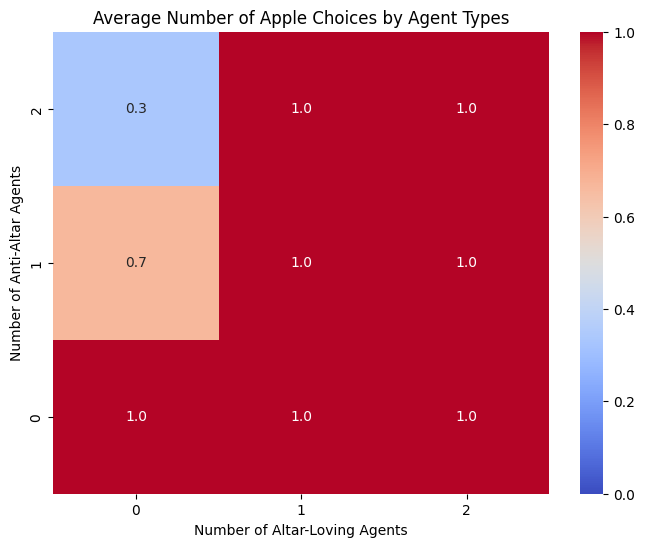

In [45]:
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt='.1f', vmin=0, vmax=1)
heatmap.invert_yaxis()
plt.title('Average Number of Apple Choices by Agent Types')
plt.xlabel('Number of Altar-Loving Agents')
plt.ylabel('Number of Anti-Altar Agents')
plt.show()

# Time taken to understand norms

Graph:
- i think what i want to graph is a the probability/density that an agent is selecting each action over time (over n time steps)
	- this probability can be estimated by using multiple trials

- an aggregate metric I can look at is the total density of taking action X, or the weighted density (i.e., we care about them taking action X more at the end after they have had time to learn the norms (or whatever))

# 